# Prédiction des émission de CO2 (GHGEmissionsIntensity)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV
from sklearn.metrics import *
from sklearn.preprocessing import LabelBinarizer, RobustScaler, OneHotEncoder

# Pour les différents modèles
from sklearn import dummy
from sklearn import linear_model
from sklearn import svm
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, BayesianRidge, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer, make_column_selector

# Feature selection et feature importance
from sklearn.feature_selection import SelectFromModel
import shap

In [3]:
data = pd.read_csv('data_clean.csv', index_col=0)

In [4]:
data

,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ENERGYSTARScore,SiteEUIWN(kBtu/sf),...,Residential Care Facility,Restaurant,Retail Store,Self-Storage Facility,Senior Care Community,Social/Meeting Hall,Strip Mall,Supermarket/Grocery Store,Urgent Care/Clinic/Other Outpatient,Worship Facility
0,Hotel,7,DOWNTOWN,1.0,12,88434,0,88434,60.0,84.300003,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Hotel,7,DOWNTOWN,1.0,11,103566,15064,88502,61.0,97.900002,...,0.0,0.044629,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Hotel,7,DOWNTOWN,1.0,41,956110,196718,759392,43.0,97.699997,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Hotel,7,DOWNTOWN,1.0,10,61320,0,61320,56.0,113.300003,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Hotel,7,DOWNTOWN,1.0,18,175580,62000,113580,75.0,118.699997,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1312,Mixed Use Property,3,CENTRAL,1.0,1,20050,0,20050,NaN,99.400002,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1313,Other,1,DELRIDGE,1.0,1,18261,0,18261,NaN,56.200001,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1314,Other,2,DOWNTOWN,1.0,1,16000,0,16000,NaN,65.900002,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1315,Mixed Use Property,1,GREATER DUWAMISH,1.0,1,14101,0,14101,NaN,55.500000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
data.dtypes.value_counts()

float64    60
int64       6
object      2
dtype: int64

In [6]:
data.columns

Index(['PrimaryPropertyType', 'CouncilDistrictCode', 'Neighborhood',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ENERGYSTARScore',
       'SiteEUIWN(kBtu/sf)', 'GHGEmissionsIntensity', 'SteamUse(ratio)',
       'Electricity(ratio)', 'NaturalGas(ratio)', 'Age', 'Adult Education',
       'Automobile Dealership', 'Bank Branch', 'College/University',
       'Courthouse', 'Data Center', 'Distribution Center', 'Financial Office',
       'Fire Station', 'Fitness Center/Health Club/Gym',
       'Hospital (General Medical & Surgical)', 'Hotel', 'K-12 School',
       'Laboratory', 'Library', 'Lifestyle Center',
       'Manufacturing/Industrial Plant', 'Medical Office', 'Movie Theater',
       'Multifamily Housing', 'Museum', 'Non-Refrigerated Warehouse', 'Office',
       'Other', 'Other - Education', 'Other - Entertainment/Public Assembly',
       'Other - Lodging/Residential', 'Other - Mall',
       'Other - Public Se

In [7]:
X = data.drop(['GHGEmissionsIntensity', 'ENERGYSTARScore', 'SiteEUIWN(kBtu/sf)', 'Age'], axis=1)
y = data['GHGEmissionsIntensity']

In [8]:
# Column_transformer
numerical_features = make_column_selector(dtype_include=np.number)
categorical_features = make_column_selector(dtype_exclude=np.number)

# Créer les pipelines de transfo des features num et cat
numerical_pipeline = make_pipeline(RobustScaler())
categorical_pipeline = make_pipeline(OneHotEncoder())

# Assembler les 2 pipelines dans le column transformer
preprocessor = make_column_transformer((numerical_pipeline, numerical_features),
                       (categorical_pipeline, categorical_features))

In [9]:
X.shape

(1317, 64)

In [10]:
# Préparation du dataframe contenant les scores des différents modèles
columns = ['Modèle', 'Paramètres', 'R²_train', 'R²_test', 'MAE', 'RMSE', 'Median_absolute_error', 'Training_time']
df_score = pd.DataFrame(columns = columns)

In [11]:
def test_model(X, y, preprocessor, model, imp=None, df_score=df_score):
    
    taille = df_score.shape[0]
    
    # Découper en train/test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    
    # Fit avec le train set
    pipeline = make_pipeline(preprocessor, model)
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    training_time = time.time() - start_time
        
    # Predict
    y_pred = pipeline.predict(X_test)
    
    df_score.loc[taille + 1] = [model,
                                model.get_params(),
                                pipeline.score(X_train, y_train),
                                pipeline.score(X_test, y_test),
                                mean_absolute_error(y_test, y_pred),
                                np.sqrt(mean_squared_error(y_test, y_pred)),
                                median_absolute_error(y_test, y_pred),
                                training_time]
    
    # Affiche le diagramme des valeurs prédites / valeurs réelles
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
    plt.text((y_test.max()/2), y_test.max(), 'R² = %.5f' % (pipeline.score(X_test, y_test)))
    plt.xlabel('y')
    plt.ylabel('y prédit')
    plt.title(model)

    return df_score

In [12]:
#Liste des modèles à tester
models = [linear_model.LinearRegression(),
          linear_model.Ridge(),
          linear_model.Lasso(),
          ElasticNet(),
          SGDRegressor(),
          RandomForestRegressor(),
          DecisionTreeRegressor(),
          XGBRegressor(),
          KNeighborsRegressor(),
          dummy.DummyRegressor(strategy='mean')]

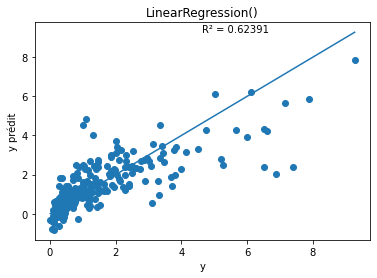

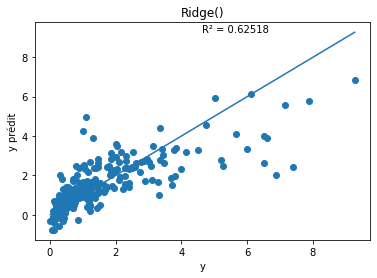

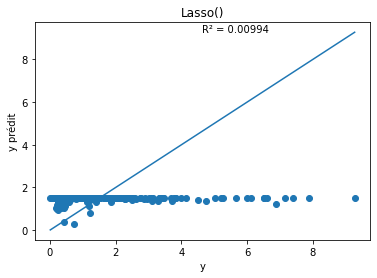

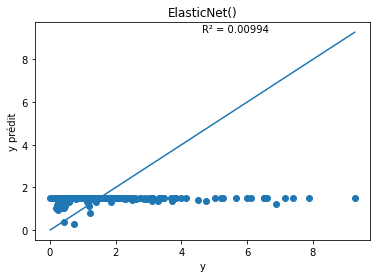

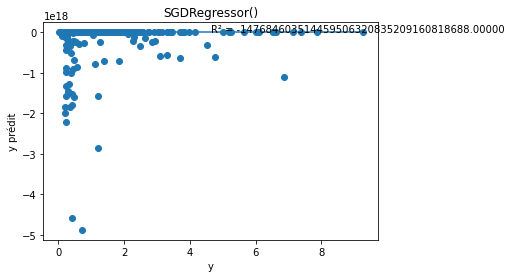

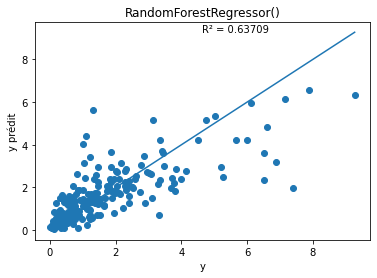

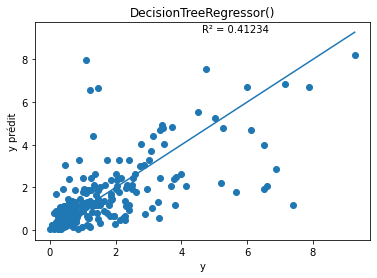

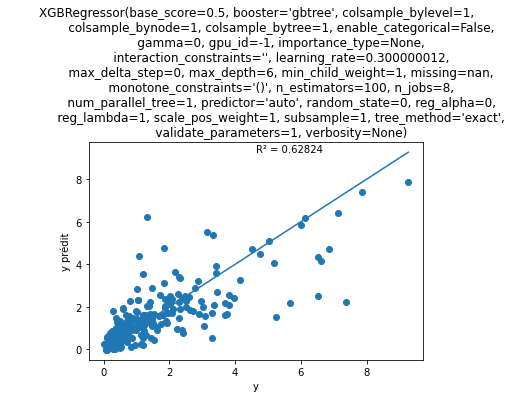

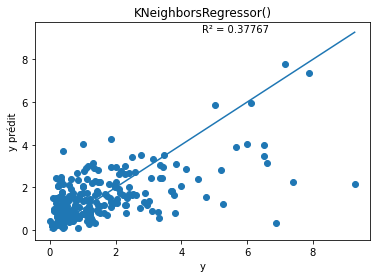

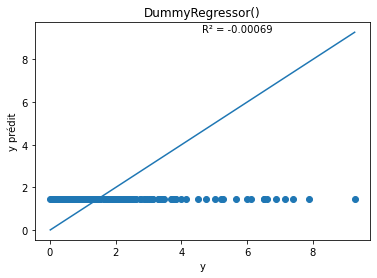

In [13]:
for mod in models:
    test_model(X, y, preprocessor, mod)

In [14]:
df_score.sort_values(by='R²_test', ascending=False)

,Modèle,Paramètres,R²_train,R²_test,MAE,RMSE,Median_absolute_error,Training_time
6,"(DecisionTreeRegressor(max_features='auto', ra...","{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...",9.459522e-01,6.370891e-01,5.550064e-01,9.574043e-01,2.624500e-01,1.216139
8,"XGBRegressor(base_score=0.5, booster='gbtree',...","{'objective': 'reg:squarederror', 'base_score'...",9.869736e-01,6.282435e-01,5.693000e-01,9.690019e-01,2.573822e-01,0.331532
2,Ridge(),"{'alpha': 1.0, 'copy_X': True, 'fit_intercept'...",6.589322e-01,6.251828e-01,6.109332e-01,9.729827e-01,3.496870e-01,0.107620
1,LinearRegression(),"{'copy_X': True, 'fit_intercept': True, 'n_job...",6.673562e-01,6.239068e-01,6.163924e-01,9.746375e-01,3.615554e-01,0.416214
7,DecisionTreeRegressor(),"{'ccp_alpha': 0.0, 'criterion': 'mse', 'max_de...",1.000000e+00,4.123385e-01,6.868182e-01,1.218313e+00,3.000000e-01,0.056345
9,KNeighborsRegressor(),"{'algorithm': 'auto', 'leaf_size': 30, 'metric...",5.409575e-01,3.776749e-01,8.265606e-01,1.253730e+00,5.960000e-01,0.030000
4,ElasticNet(),"{'alpha': 1.0, 'copy_X': True, 'fit_intercept'...",1.196661e-02,9.940838e-03,1.143500e+00,1.581342e+00,9.734751e-01,0.030336
3,Lasso(),"{'alpha': 1.0, 'copy_X': True, 'fit_intercept'...",1.196661e-02,9.940717e-03,1.143500e+00,1.581343e+00,9.734753e-01,0.101972
10,DummyRegressor(),"{'constant': None, 'quantile': None, 'strategy...",0.000000e+00,-6.861753e-04,1.149018e+00,1.589807e+00,1.015646e+00,0.028942
5,SGDRegressor(),"{'alpha': 0.0001, 'average': False, 'early_sto...",-2.096808e+35,-1.476846e+35,1.914165e+17,6.107493e+17,6.470061e+10,0.057111


In [15]:
# Implémenter la CV avec GridSearchCV pour trouver les meilleurs hyperparamètres pour chaque modèle

In [16]:
# Dataframe des scores avec GridSearchCV
columns = ['Modèle', 'Meilleurs paramètres', 'R²_train', 'R²_test', 'MAE', 'RMSE', 'Median absolute error', 'Training_time']
df_score_CV = pd.DataFrame(columns = columns)

In [17]:
# Créer une classe pour associer modèles et param_grid
class models_cv:
    def __init__(self, model, param_grid):
        self.model = model
        self.param_grid = param_grid

In [18]:
# Instancier tous les modèles
linear_reg = models_cv(model = linear_model.LinearRegression(),
                       param_grid = {'fit_intercept': [True, False]}
                      )
ridge = models_cv(model = linear_model.Ridge(),
                  param_grid = {'alpha': [5.0, 2.0, 1.0, 0.8, 0.6, 0.4, 0.2, 0]}
                 )
lasso = models_cv(model = linear_model.Lasso(max_iter=12000),
                  param_grid = {'alpha': [5.0, 2.0, 1.0, 0.8, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01, 0.005, 0.002, 0.001]}
                 )
elastic_net = models_cv(model = ElasticNet(max_iter=5000),
                        param_grid = {'alpha': [5.0, 2.0, 1.0, 0.5, 0.1, 0.05, 0.01],
                                      'l1_ratio' : [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]}
                       )
SGDreg = models_cv(model = SGDRegressor(),
                   param_grid = {'alpha': [1.0, 0.8, 0.5, 0.2, 0.1, 0.05, 0.01, 0.001, 0.0001]}
                  )
random_forest_reg = models_cv(model = RandomForestRegressor(),
                              param_grid = {'n_estimators': [50, 100, 200, 300]}
                             )
decision_tree_reg = models_cv(model = DecisionTreeRegressor(),
                              param_grid = {'criterion': ["mse", "friedman_mse", "mae", "poisson"]}
                             )
XGB_reg = models_cv(model = XGBRegressor(),
                    param_grid = {'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5]}
                   )
KN_reg = models_cv(model = KNeighborsRegressor(),
                   param_grid = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8]}
                  )

In [19]:
# Liste des modèles
model_cv_list = [linear_reg, ridge, lasso, elastic_net, SGDreg, random_forest_reg, decision_tree_reg, XGB_reg, KN_reg]

In [20]:
#Définir une fonction qui retourne les scores optimisés avec GridSearchCV

def scoreCV(X, y, preprocessor, model_cv, df_score_CV):
    taille = df_score_CV.shape[0]
    
    # Découper en train/test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    
    # Recherche des meilleurs paramètres
    grid = GridSearchCV(model_cv.model,
                        model_cv.param_grid,
                        cv=5,
                        return_train_score=True,
                        refit=True,
                       scoring='r2')
    
    pipeline = make_pipeline(preprocessor, grid)

    start_time = time.time()
    pipeline.fit(X_train, y_train)
    training_time = time.time() - start_time
        
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Enregistrer les meilleurs paramètres du modèle
    model_cv.best_params = grid.best_params_
    
    # Remplir le tableau des résultats
    df_score_CV.loc[taille + 1] = [model_cv.model,
                                grid.best_params_,
                                pipeline.score(X_train, y_train),
                                pipeline.score(X_test, y_test),
                                mean_absolute_error(y_test, y_pred),
                                np.sqrt(mean_squared_error(y_test, y_pred)),
                                median_absolute_error(y_test, y_pred),
                                training_time]
    
    return df_score_CV

In [21]:
for mod in model_cv_list:
    scoreCV(X, y, preprocessor, mod, df_score_CV)

{'fit_intercept': False}
{'alpha': 2.0}


Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.30987739287502336, tolerance: 0.28607550365795725
Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.2806875588090634, tolerance: 0.2659950073546857


{'alpha': 0.002}
{'alpha': 0.01, 'l1_ratio': 0.1}
{'alpha': 1.0}
{'n_estimators': 100}
{'criterion': 'mae'}
{'learning_rate': 0.1}
{'n_neighbors': 8}


In [22]:
df_score_CV.sort_values(by='R²_test', ascending=False)

,Modèle,Meilleurs paramètres,R²_train,R²_test,MAE,RMSE,Median absolute error,Training_time
8,"XGBRegressor(base_score=None, booster=None, co...",{'learning_rate': 0.1},9.325700e-01,6.378403e-01,5.646832e-01,9.564129e-01,2.465962e-01,4.926419
6,RandomForestRegressor(),{'n_estimators': 100},9.430277e-01,6.351559e-01,5.454447e-01,9.599509e-01,2.486000e-01,28.040720
3,Lasso(max_iter=12000),{'alpha': 0.002},6.532235e-01,6.285553e-01,6.011051e-01,9.685955e-01,3.108031e-01,4.363667
2,Ridge(),{'alpha': 2.0},6.537535e-01,6.256378e-01,6.090570e-01,9.723919e-01,3.267460e-01,0.332356
1,LinearRegression(),{'fit_intercept': False},6.673562e-01,6.239068e-01,6.163924e-01,9.746375e-01,3.615554e-01,0.106868
4,ElasticNet(max_iter=5000),"{'alpha': 0.01, 'l1_ratio': 0.1}",6.143565e-01,6.120242e-01,6.147367e-01,9.899144e-01,3.572093e-01,2.664374
9,KNeighborsRegressor(),{'n_neighbors': 8},4.941320e-01,3.776339e-01,8.169508e-01,1.253771e+00,5.537500e-01,0.881439
7,DecisionTreeRegressor(),{'criterion': 'mae'},1.000000e+00,2.964649e-01,7.578030e-01,1.333025e+00,3.750000e-01,1.613120
5,SGDRegressor(),{'alpha': 1.0},-1.716955e+34,-1.209304e+34,5.477464e+16,1.747685e+17,2.398535e+10,0.525701


## Feature selection

In [23]:
# Avec le selector
def test_model_selector(X, y, preprocessor, mod, imp=None, df_score=df_score):
    
    taille = df_score.shape[0]
    
    # Récupération des meilleurs hyperparamètres du model
    modele = mod.model
    modele.set_params(**mod.best_params)
    
    # Découper en train/test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    
    # Ajout du selector
    selector = SelectFromModel(modele, threshold='mean')
    
    # Fit avec le train set
    pipeline = make_pipeline(preprocessor, selector, modele)
    
    pipeline.fit(X_train, y_train)
        
    # Predict
    y_pred = pipeline.predict(X_test)
    
    df_score.loc[taille + 1] = [modele,
                                modele.get_params(),
                                pipeline.score(X_train, y_train),
                                pipeline.score(X_test, y_test),
                                mean_absolute_error(y_test, y_pred),
                                np.sqrt(mean_squared_error(y_test, y_pred)),
                                median_absolute_error(y_test, y_pred)]
    
    # Affiche le diagramme des valeurs prédites / valeurs réelles
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
    plt.xlabel('y')
    plt.ylabel('y prédit')
    plt.title(modele)
    
    #importance = model.coef_
    # summarize feature importance
    #for i,v in enumerate(importance):
    #    print('Feature: %0d, Score: %.5f' % (i,v))
    # plot feature importance
    #plt.bar([x for x in range(len(importance))], importance)
    #plt.show()

    return df_score

In [24]:
# Préparation du dataframe contenant les scores des différents modèles
columns = ['Modèle', 'Paramètres', 'R²_train', 'R²_test', 'MAE', 'RMSE', 'Median absolute error']
df_score_feature_selection = pd.DataFrame(columns = columns)

In [25]:
# Pour la feature selection avec SelecteFromModel, suppression du KNN car ni coef ni importance
model_cv_list.remove(KN_reg)

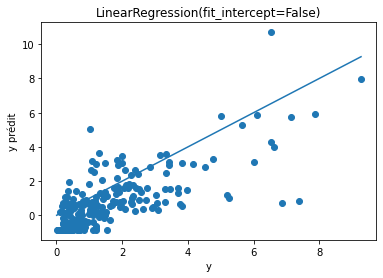

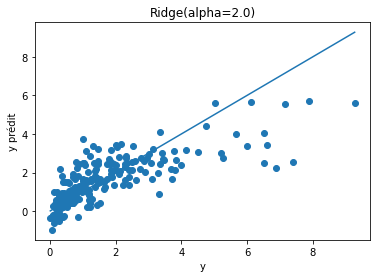

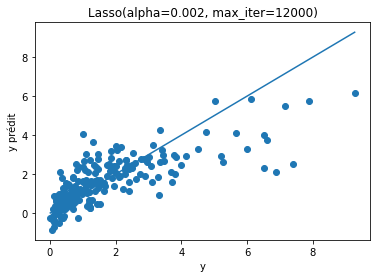

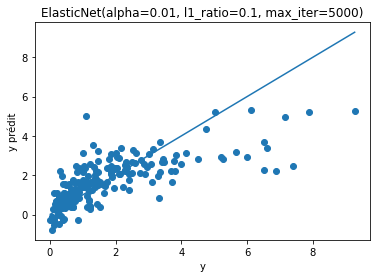

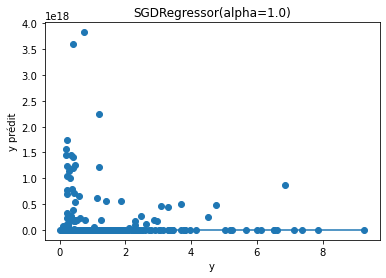

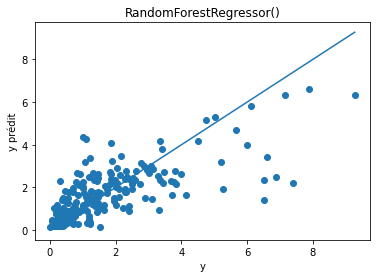

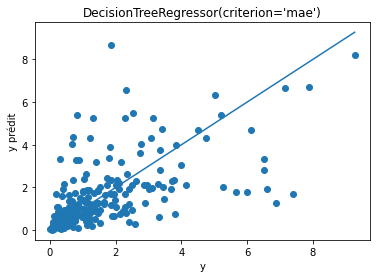

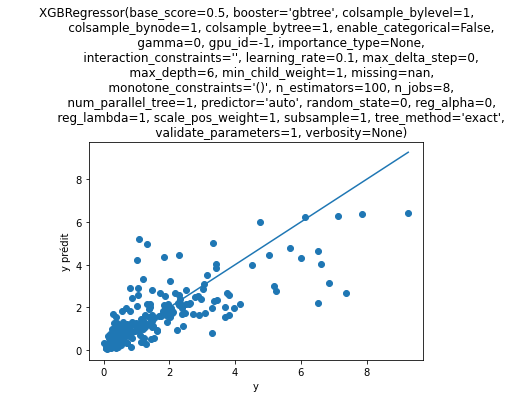

In [26]:
for mod in model_cv_list:
    test_model_selector(X, y, preprocessor, mod, imp=None, df_score=df_score_feature_selection)

In [27]:
df_score_feature_selection.sort_values(by='R²_test', ascending=False)

,Modèle,Paramètres,R²_train,R²_test,MAE,RMSE,Median absolute error
3,"Lasso(alpha=0.002, max_iter=12000)","{'alpha': 0.002, 'copy_X': True, 'fit_intercep...",6.430437e-01,6.375793e-01,5.967895e-01,9.567574e-01,3.067814e-01
8,"XGBRegressor(base_score=0.5, booster='gbtree',...","{'objective': 'reg:squarederror', 'base_score'...",9.166734e-01,6.340432e-01,5.607858e-01,9.614136e-01,2.591661e-01
2,Ridge(alpha=2.0),"{'alpha': 2.0, 'copy_X': True, 'fit_intercept'...",6.364758e-01,6.324813e-01,6.109196e-01,9.634630e-01,3.495473e-01
4,"ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=...","{'alpha': 0.01, 'copy_X': True, 'fit_intercept...",6.027654e-01,5.990313e-01,6.269623e-01,1.006354e+00,3.693200e-01
6,"(DecisionTreeRegressor(max_features='auto', ra...","{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...",9.367487e-01,5.882749e-01,6.083708e-01,1.019762e+00,3.282000e-01
7,DecisionTreeRegressor(criterion='mae'),"{'ccp_alpha': 0.0, 'criterion': 'mae', 'max_de...",1.000000e+00,3.011039e-01,7.645076e-01,1.328623e+00,3.400000e-01
1,LinearRegression(fit_intercept=False),"{'copy_X': True, 'fit_intercept': False, 'n_jo...",3.449094e-01,2.207767e-01,1.117688e+00,1.402899e+00,1.058053e+00
5,SGDRegressor(alpha=1.0),"{'alpha': 1.0, 'average': False, 'early_stoppi...",-1.290321e+35,-9.088126e+34,1.501581e+17,4.791070e+17,1.027894e+10


In [28]:
# La feature selection à partir de SelectFromModel (sélection des variables dont le coefficient en supérieur à la moyenne) permet d'améliorer les modèles Lasso et Ridge 

## Optimisation avec le modèle Lasso

In [29]:
# Récupération des features selected
    
# Récupération des meilleurs hyperparamètres du model
modele = lasso.model
modele.set_params(**lasso.best_params)
    
# Découper en train/test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    
# Ajout du selector
selector = SelectFromModel(modele, threshold='mean')
    
# Fit avec le train set
pipeline = make_pipeline(preprocessor, selector, modele)
pipeline.fit(X_train, y_train)
        
# Predict
y_pred = pipeline.predict(X_test)
    
print('coefficients : ', selector.estimator_.coef_, 'threshold : ', selector.threshold_)

coefficients :  [-3.49831106e-01  2.73762106e-01  2.30559637e-02 -0.00000000e+00
 -9.87637475e-07 -1.23401087e-02  1.62376273e+00 -1.75211397e+00
 -1.02485225e-02 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
  0.00000000e+00  0.00000000e+00  2.32548545e-02  3.19576515e+00
  3.69755634e-01 -7.76433635e-01  2.53201764e+00 -0.00000000e+00
  0.00000000e+00 -0.00000000e+00  5.37649683e-02  0.00000000e+00
 -0.00000000e+00  8.32435499e-01 -6.43020741e-01  1.25877426e-02
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -3.61708018e-01
  7.29663894e-01  0.00000000e+00  7.85731433e-01  0.00000000e+00
  0.00000000e+00 -0.00000000e+00  1.99750011e+00 -2.24528566e-01
 -0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00  0.00000000e+00 -1.50013087e-01 -0.00000000e+00
  0.00000000e+00  1.60704046e+00 -2.27582772e-02 -9.62450006e-01
  1.44933555e+00 -8.52932594e-02  0.00000000e+00  3.35564827e+00
 -0.00000

In [30]:
feature_names = np.concatenate((preprocessor.transformers_[0][2], 
                                                preprocessor.transformers_[1][1][0].categories_[0], 
                                                preprocessor.transformers_[1][1][0].categories_[1]), axis=None)
selected_features = list(np.array(feature_names)[selector.get_support()])


In [31]:
selected_features = list(np.array(feature_names)[selector.get_support()])

In [32]:
len(feature_names)

95

In [33]:
len(selected_features)

21

In [34]:
# Sur les 95 features (après one hot encodage) seules 21 sont sélectionnées

In [35]:
# Feature importance with SHAP

In [36]:
modele

Lasso(alpha=0.002, max_iter=12000)

In [37]:
shap.initjs()

In [38]:
# SHAP
pipeline.fit(X_train, y_train)
pipeline.score(X_test, y_test)

0.6375793494452924

In [39]:
preprocessed = preprocessor.transform(X_train)

In [40]:
selector.transform(preprocessed)

array([[-0.4       ,  0.        , -0.00404394, ...,  0.        ,
         0.        ,  0.        ],
       [-0.4       ,  0.        , -0.11555906, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.57139949, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.2       ,  0.        , -1.16227688, ...,  0.        ,
         0.        ,  0.        ],
       [-0.2       ,  0.        , -0.52293297, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.6       ,  0.        , -0.32762559, ...,  0.        ,
         0.        ,  0.        ]])

In [41]:
lin_reg_explainer1 = shap.LinearExplainer(modele, selector.transform(preprocessed))

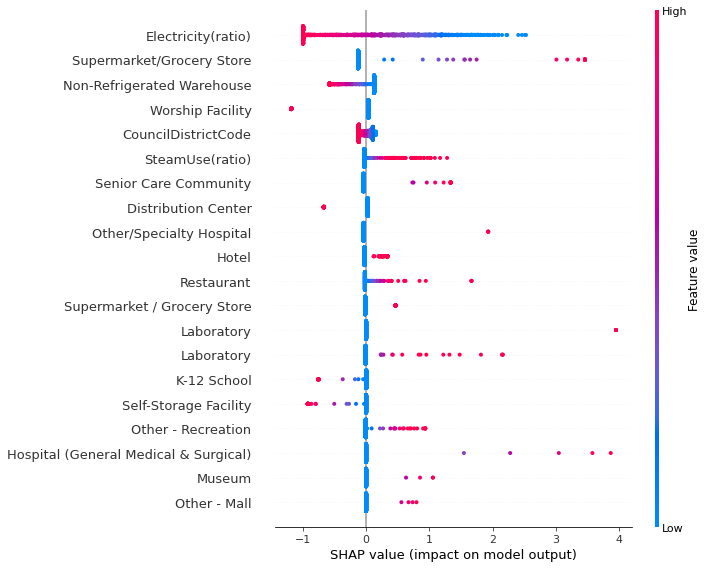

In [42]:
shap.summary_plot(lin_reg_explainer1.shap_values(selector.transform(preprocessed)),
                  features = selector.transform(preprocessed),
                # Récupérer les noms de variables après preprocess
                  feature_names = selected_features
                     )

In [43]:
# Avec le EnergyStarScore

In [44]:
# Charger le dataframe avec uniquement les bâtiments pour lesquels le score est connu
data_energy_star_score = pd.read_csv('df_energy_star_score.csv', index_col=0)

In [45]:
X = data_energy_star_score.drop(axis=1, labels=['SiteEUIWN(kBtu/sf)', 'GHGEmissionsIntensity', 'Age'])
y = data_energy_star_score['GHGEmissionsIntensity']

In [46]:
# Découper en train/test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

 R² =  0.7798858466240455


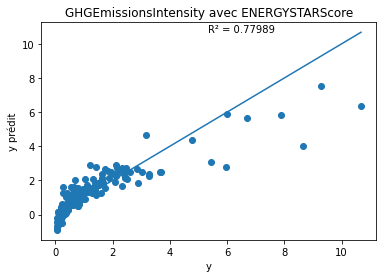

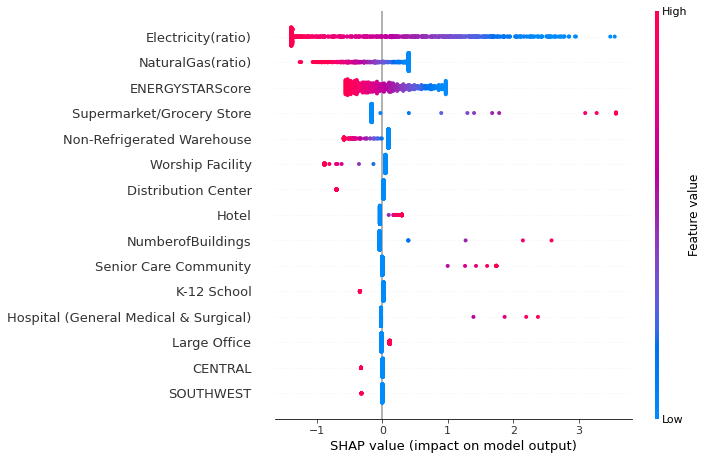

In [47]:
# Fit avec le train set
pipeline = make_pipeline(preprocessor, selector , modele)
pipeline.fit(X_train, y_train)

# SHAP
preprocessed = preprocessor.transform(X_train)
lin_reg_explainer1 = shap.LinearExplainer(modele, selector.transform(preprocessed))
        
# Predict
y_pred = pipeline.predict(X_test)

print(' R² = ', pipeline.score(X_test, y_test))

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.text((y_test.max()/2), y_test.max(), 'R² = %.5f' % (pipeline.score(X_test, y_test)))
plt.xlabel('y')
plt.ylabel('y prédit')
plt.title('GHGEmissionsIntensity avec ENERGYSTARScore')
plt.show()

# Récupérer les features names
feature_names = np.concatenate((preprocessor.transformers_[0][2], 
                                                preprocessor.transformers_[1][1][0].categories_[0], 
                                                preprocessor.transformers_[1][1][0].categories_[1]), axis=None)
selected_features = list(np.array(feature_names)[selector.get_support()])

plt.figure()
shap.summary_plot(lin_reg_explainer1.shap_values(selector.transform(preprocessed)),
                  features = selector.transform(preprocessed),
                # Récupérer les noms de variables après preprocess
                  feature_names = selected_features
                     )

In [48]:
# Vérification avec ce jeu de donné sans le ESS
X_2 = data_energy_star_score.drop(axis=1, labels=['SiteEUIWN(kBtu/sf)', 'ENERGYSTARScore', 'GHGEmissionsIntensity', 'Age'])

In [49]:
# Découper en train/test set
X_train, X_test, y_train, y_test = train_test_split(X_2, y, test_size=0.2, random_state=0)

 R² =  0.6747197538180019


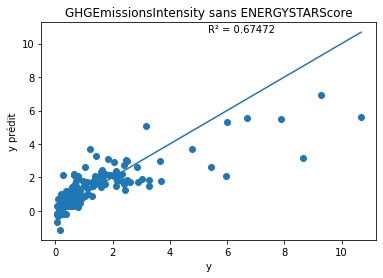

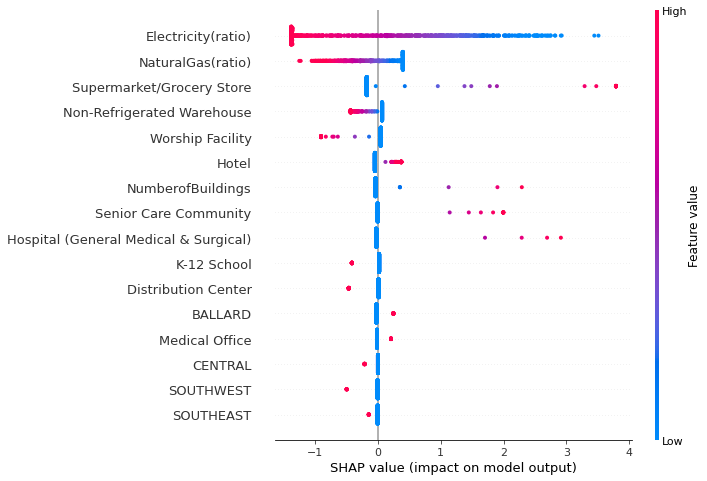

In [50]:
# Fit avec le train set
pipeline = make_pipeline(preprocessor, selector, modele)
pipeline.fit(X_train, y_train)

# SHAP
preprocessed = preprocessor.transform(X_train)
lin_reg_explainer1 = shap.LinearExplainer(modele, selector.transform(preprocessed))
        
# Predict
y_pred = pipeline.predict(X_test)

print(' R² = ', pipeline.score(X_test, y_test))

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.text((y_test.max()/2), y_test.max(), 'R² = %.5f' % (pipeline.score(X_test, y_test)))
plt.xlabel('y')
plt.ylabel('y prédit')
plt.title('GHGEmissionsIntensity sans ENERGYSTARScore')
plt.show()

# Récuperer les features names
feature_names = np.concatenate((preprocessor.transformers_[0][2], 
                                                preprocessor.transformers_[1][1][0].categories_[0], 
                                                preprocessor.transformers_[1][1][0].categories_[1]), axis=None)
selected_features = list(np.array(feature_names)[selector.get_support()])

plt.figure()
shap.summary_plot(lin_reg_explainer1.shap_values(selector.transform(preprocessed)),
                  features = selector.transform(preprocessed),
                # Récupérer les noms de variables après preprocess
                  feature_names = selected_features
                     )